Table 1- Summary Statistics

In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/clean/merged_final.csv', parse_dates=['month'])
df = df[df['month'] <= '2025-12-01']

# Create total patronage if missing
patronage_cols = [
    'Metropolitan train', 'Metropolitan tram', 'Metropolitan bus',
    'Regional train', 'Regional coach', 'Regional bus'
]
if 'total_patronage' not in df.columns:
    df['total_patronage'] = df[patronage_cols].sum(axis=1)

# Select key variables
vars_of_interest = ['PetrolPrice', 'total_patronage', 'rainfall_mm', 'population', 'public_holiday_count']

# Create summary stats from numeric data first
summary = df[vars_of_interest].describe().T[['count', 'mean', 'std', 'min', 'max']].copy()
summary.columns = ['N', 'Mean', 'Std Dev', 'Min', 'Max']
summary['N'] = summary['N'].astype(int)
summary.index = ['Petrol Price ($/L)', 'Total Patronage (persons)', 
                 'Rainfall (mm)', 'Population', 'Public Holiday Count']

# Build formatted display table as a fresh DataFrame
rows = []
for idx in summary.index:
    n = summary.loc[idx, 'N']
    vals = summary.loc[idx, ['Mean', 'Std Dev', 'Min', 'Max']].values.astype(float)
    
    if 'Total Patronage' in idx or 'Population' in idx:
        formatted = [f"{int(round(v)):,}" for v in vals]
    elif 'Rainfall' in idx:
        formatted = [f"{v:.1f}" for v in vals]
    elif 'Public Holiday' in idx:
        formatted = [f"{int(round(v))}" for v in vals]
    else:
        formatted = [f"{v:.3f}" for v in vals]
    
    rows.append([n] + formatted)

display_summary = pd.DataFrame(
    rows,
    index=summary.index,
    columns=['N', 'Mean', 'Std Dev', 'Min', 'Max']
)

print(display_summary.to_string())

                            N        Mean    Std Dev         Min         Max
Petrol Price ($/L)         48       1.883      0.098       1.590       2.120
Total Patronage (persons)  48  38,286,542  5,665,614  16,553,521  47,552,413
Rainfall (mm)              48        50.8       33.0         2.8       149.0
Population                 48   6,921,754    130,349   6,714,248   7,104,348
Public Holiday Count       48           1          1           0           5


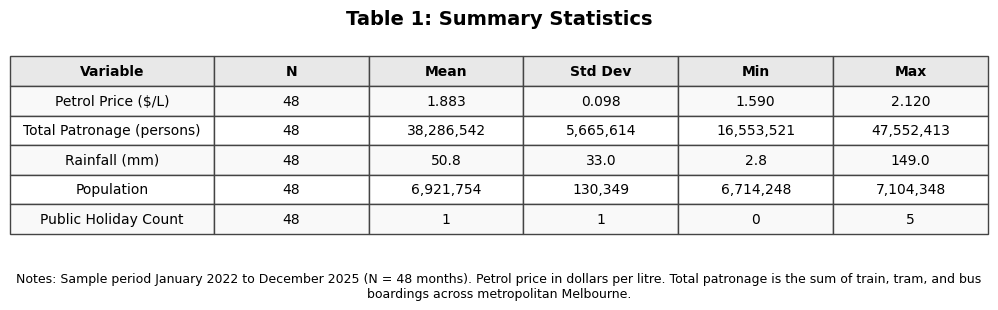

In [18]:
import os
import matplotlib.pyplot as plt

# Build a cleaner screenshot-friendly table image
styled = display_summary.copy().reset_index()
styled.rename(columns={'index': 'Variable'}, inplace=True)

num_cols = len(styled.columns)
col_widths = [0.25] + [0.19] * (num_cols - 1)
fig_width = max(10, num_cols * 1.1)
fig, ax = plt.subplots(figsize=(fig_width, 3.2))
ax.axis('off')
ax.set_title('Table 1: Summary Statistics', fontsize=14, fontweight='bold', pad=16)

header_color = ['#e8e8e8'] * num_cols

table = ax.table(
    cellText=styled.values,
    colLabels=styled.columns,
    cellLoc='center',
    loc='center',
    colColours=header_color,
    colWidths=col_widths
)

table.auto_set_font_size(False)
table.set_fontsize(10)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#444444')
    cell.set_height(0.15)
    if row == 0:
        cell.set_facecolor('#e8e8e8')
        cell.get_text().set_weight('bold')
    elif row % 2 == 1:
        cell.set_facecolor('#f9f9f9')
    else:
        cell.set_facecolor('#ffffff')

# Add a footnote and save both PNG and PDF for high-quality export
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
note = (
    f"Notes: Sample period January 2022 to December 2025 (N = {len(df)} months). "
    "Petrol price in dollars per litre. Total patronage is the sum of train, tram, and bus "
    "boardings across metropolitan Melbourne."
)
# Place the note below the table
fig.text(0.5, 0.06, note, ha='center', fontsize=9, wrap=True)

os.makedirs('../output', exist_ok=True)
fig.savefig('../output/table1_summary.png', dpi=220, bbox_inches='tight')
fig.savefig('../output/table1_summary.pdf', dpi=220, bbox_inches='tight')
plt.show()

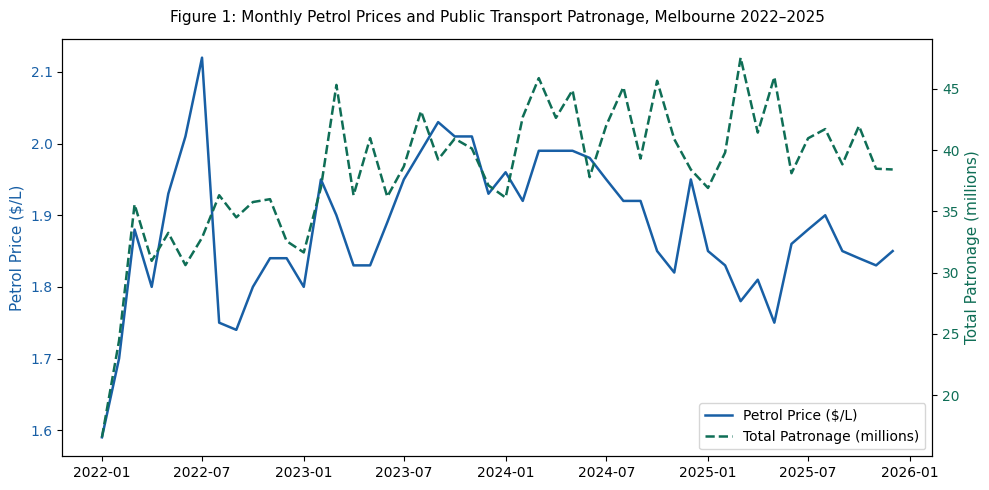

Figure 1 saved to output/figure1_timeseries.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax1 = plt.subplots(figsize=(10, 5))

# Petrol price on left axis
ax1.plot(df['month'], df['PetrolPrice'], color='#185FA5', linewidth=1.8, label='Petrol Price ($/L)')
ax1.set_ylabel('Petrol Price ($/L)', color='#185FA5', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#185FA5')
ax1.set_xlabel('')

# Patronage on right axis
ax2 = ax1.twinx()
ax2.plot(df['month'], df['total_patronage']/1e6, color='#0F6E56', linewidth=1.8, linestyle='--', label='Total Patronage (millions)')
ax2.set_ylabel('Total Patronage (millions)', color='#0F6E56', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#0F6E56')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=10)

plt.title('Figure 1: Monthly Petrol Prices and Public Transport Patronage, Melbourne 2022–2025', fontsize=11, pad=12)
fig.tight_layout()
plt.savefig('../output/figure1_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved to output/figure1_timeseries.png")

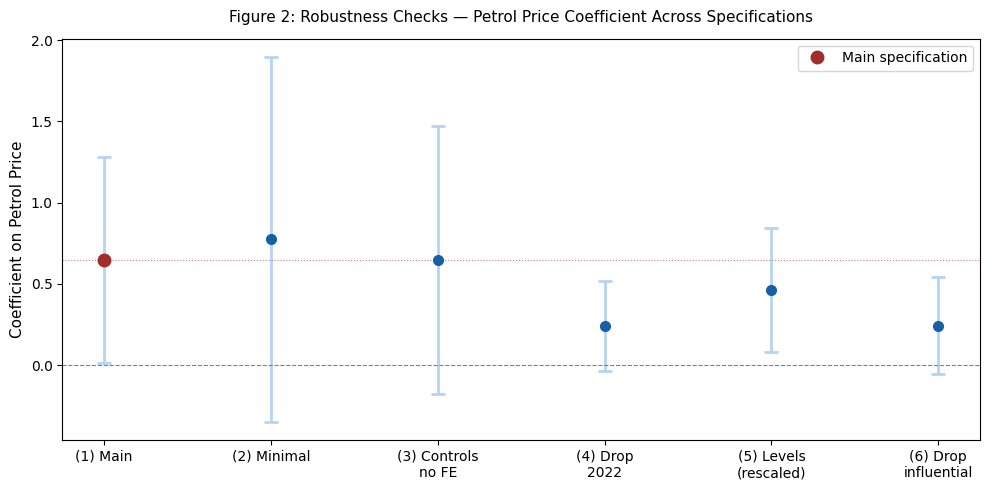

Figure 2 saved to output/figure2_coefplot.png


In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Robustness check results
specs = ['(1) Main', '(2) Minimal', '(3) Controls\nno FE', '(4) Drop\n2022', '(5) Levels\n(rescaled)', '(6) Drop\ninfluential']
coefs = [0.6483, 0.7739, 0.6480, 0.2408, 0.6483, 0.2434]
ses   = [0.3240, 0.5733, 0.4217, 0.1411, 0.3240, 0.1520]

# Note: col 5 (levels) is rescaled — divide by mean patronage for comparability
# 17,667,943 / 38,286,542 ≈ 0.461 as a proportion
coefs[4] = 17667943 / 38286542
ses[4]   = 7448140  / 38286542

coefs = np.array(coefs)
ses   = np.array(ses)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#A32D2D' if i == 0 else '#185FA5' for i in range(len(specs))]

ax.errorbar(range(len(specs)), coefs, yerr=1.96*ses,
            fmt='o', color='#185FA5', ecolor='#B5D4F4',
            elinewidth=2, capsize=5, capthick=2, markersize=7)

# Colour main spec differently
ax.plot(0, coefs[0], 'o', color='#A32D2D', markersize=9, zorder=5, label='Main specification')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axhline(coefs[0], color='#A32D2D', linewidth=0.8, linestyle=':', alpha=0.6)

ax.set_xticks(range(len(specs)))
ax.set_xticklabels(specs, fontsize=10)
ax.set_ylabel('Coefficient on Petrol Price', fontsize=11)
ax.set_title('Figure 2: Robustness Checks — Petrol Price Coefficient Across Specifications', fontsize=11, pad=12)
ax.legend(fontsize=10)

fig.tight_layout()
plt.savefig('../output/figure2_coefplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved to output/figure2_coefplot.png")